# Quantum Machine Learning with a TwoLocal Variational Classifier — 4-Label Checkerboard

This notebook trains and evaluates a **variational quantum classifier** on a
2-D, **4-class** checkerboard dataset (`checkerboard-4L-4Q`), available in
**10 independent instances** (`dataset1` … `dataset10`).

This is the multiclass counterpart of the binary-classification notebook in the
repository root ([`Parallel_QML.ipynb`](../Parallel_QML.ipynb)) — same overall
workflow, but a different circuit:

- a **ZZFeatureMap** to encode the two input features, and
- a **TwoLocal** (`ry`, `rz`, `cz`, *full* entanglement) variational ansatz
  acting on **4 qubits** (2 encoding qubits + 2 extra readout qubits, giving a
  **2-bit** label readout for the 4 classes), re-uploaded **2 times**, trained
  with the **SPSA** optimizer.

Two circuit constructions are provided:
- **Method 1** — one circuit per data point (standard per-sample evaluation).
- **Method 2** — all data points encoded in superposition through an index
  register (amplitude/QRAM-style batch encoding).

## How to use this notebook
1. Edit the **Configuration** cell below to choose a dataset instance and a run mode.
2. *Run All*. Everything else (loading, training/loading results, plots, metrics)
   happens automatically and is displayed inline.

> **Tip:** Set `MODE = "load"` to instantly visualize the pre-computed results that
> ship with this repository, or `MODE = "train"` to reproduce a run from scratch.

> **Note:** unlike the root notebook, this notebook is meant to be run with its
> working directory set to `multiclass/` — it reads from `datasets/dataset<N>/`
> and `results/checkerboard-4L-4Q-dataset<N>/` relative to this folder.

## 1. Configuration  *(the only cell you ned to edit)*

In [1]:
# ============================ USER SETTINGS ============================
# Pick the instance:  an integer from 1 to 10
DATASET_NUM = 1

# What to do:
#   "load"  -> read the pre-computed results shipped in this repo (fast, no training)
#   "train" -> train the model live with SPSA (slower, fully reproducible)
MODE = "load"

# Which circuit construction(s) to run / display:
#   [1]    -> only Method 1 (one circuit per sample)
#   [2]    -> only Method 2 (all samples in superposition)
#   [1, 2] -> both, shown side by side
METHODS = [1, 2]

# --- settings used only when MODE == "train" ---
MAXITER = 400          # SPSA iterations (the shipped results used ~400)
SEED    = 42            # random seed for the initial parameters (reproducibility)
USE_GPU = False         # try the GPU Aer backend for Method 2 (needs qiskit-aer-gpu)

# --- visualization ---
PLOT_DECISION_BOUNDARY = False   # draw the learned decision boundary (a bit slower)
GRID_RES = 60                    # resolution of the decision-boundary grid
# ======================================================================

assert 1 <= DATASET_NUM <= 10
assert MODE in {"load", "train"}
assert all(m in (1, 2) for m in METHODS) and len(METHODS) >= 1
print(f"Dataset : checkerboard-4L-4Q / dataset{DATASET_NUM}")
print(f"Mode    : {MODE}   |   Method(s): {METHODS}")

Dataset : checkerboard-4L-4Q / dataset1
Mode    : load   |   Method(s): [1, 2]


## 2. Imports

In [2]:
import os
import json
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import ZZFeatureMap, TwoLocal, XGate
from qiskit.quantum_info import partial_trace
from qiskit_aer import AerSimulator
# NOTE: SPSA (from qiskit_machine_learning) is imported lazily in the training
# cell, so that "load" mode works even without qiskit_machine_learning installed.

warnings.filterwarnings("ignore")   # silence qiskit deprecation chatter
np.random.seed(SEED)

# 4 discrete colors used throughout for the 4 classes (0, 1, 2, 3)
CLASS_COLORS = ListedColormap(["#3b4cc0", "#7ea0f9", "#f7a889", "#b40426"])
CLASS_NORM   = BoundaryNorm(np.arange(-0.5, 4.5, 1), CLASS_COLORS.N)

## 3. Load the selected dataset

Train data : (128, 2),  labels: (128,)
Test  data : (64, 2),  labels: (64,)
Classes    : [0, 1, 2, 3]


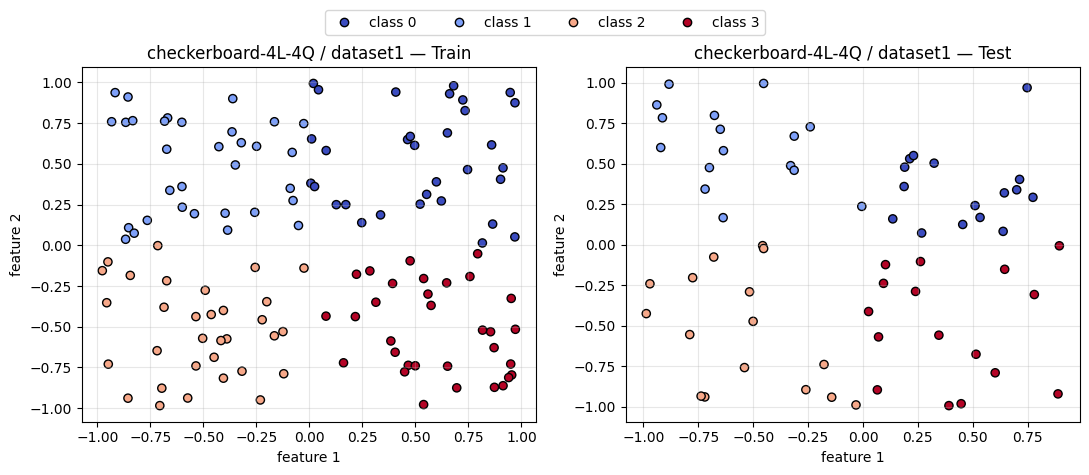

In [3]:
DATA_DIR    = os.path.join("datasets", f"dataset{DATASET_NUM}")
RESULTS_DIR = os.path.join("results",  f"checkerboard-4L-4Q-dataset{DATASET_NUM}")

train_data   = pd.read_csv(os.path.join(DATA_DIR, "train_data")).to_numpy()
train_labels = pd.read_csv(os.path.join(DATA_DIR, "train_labels")).to_numpy().flatten()
test_data    = pd.read_csv(os.path.join(DATA_DIR, "test_data")).to_numpy()
test_labels  = pd.read_csv(os.path.join(DATA_DIR, "test_labels")).to_numpy().flatten()

print(f"Train data : {train_data.shape},  labels: {train_labels.shape}")
print(f"Test  data : {test_data.shape},  labels: {test_labels.shape}")
print(f"Classes    : {sorted(np.unique(train_labels).tolist())}")

# Quick look at the raw data
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, X, y, name in [(axes[0], train_data, train_labels, "Train"),
                       (axes[1], test_data,  test_labels,  "Test")]:
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CLASS_COLORS, norm=CLASS_NORM,
               edgecolors="k", s=35)
    ax.set_title(f"checkerboard-4L-4Q / dataset{DATASET_NUM} — {name}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.grid(alpha=0.3)
handles = [plt.Line2D([0], [0], marker="o", color="w", markeredgecolor="k",
                      markerfacecolor=CLASS_COLORS(i), label=f"class {i}")
          for i in range(4)]
fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(); plt.show()

## 4. Quantum-circuit hyperparameters

In [4]:
num_reupload   = 2
num_register   = int(np.log2(len(train_data)))
num_features   = len(train_data[0])
num_ansatz_q   = 2 * num_features   # 2 encoding qubits + 2 extra readout qubits -> 2-bit label
num_parameters = num_reupload * TwoLocal(num_ansatz_q, ['ry', 'rz'], 'cz', 'full', reps=1).num_parameters

print(f"Re-uploads        : {num_reupload}")
print(f"Encoding qubits   : {num_features}")
print(f"Ansatz qubits     : {num_ansatz_q}  (encoding + readout register)")
print(f"Index register    : {num_register} qubits  (Method 2)")
print(f"Trainable params  : {num_parameters}")
print(f"Classes           : 4  (2-bit readout: '00', '01', '10', '11')")

Re-uploads        : 2
Encoding qubits   : 2
Ansatz qubits     : 4  (encoding + readout register)
Index register    : 7 qubits  (Method 2)
Trainable params  : 32
Classes           : 4  (2-bit readout: '00', '01', '10', '11')


## 5. Circuit definitions

**Method 1** builds one circuit per data point. **Method 2** encodes the whole
dataset in superposition using an index register. The two encoder/variational
sub-circuits below are drawn for reference.

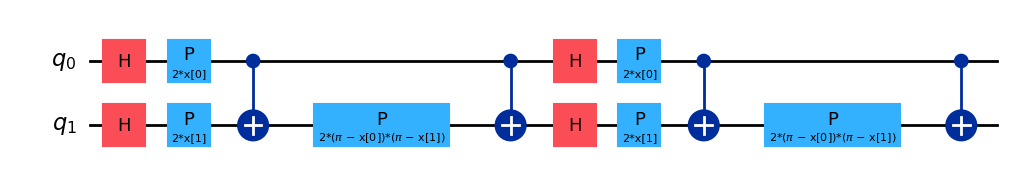

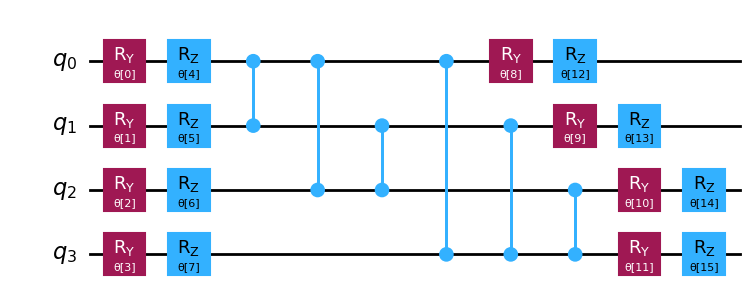

In [5]:
# Reference drawings of the building blocks
display(ZZFeatureMap(feature_dimension=num_features).decompose().draw('mpl'))
display(TwoLocal(num_ansatz_q, ['ry', 'rz'], 'cz', 'full', reps=1).decompose().draw('mpl'))

In [6]:
def qc1(data, variational):
    """Method 1: a single circuit for one data point `data`."""
    n = num_features
    qreg1 = QuantumRegister(n, 'q')   # encoding register
    qreg2 = QuantumRegister(n, 'p')   # extra readout register
    qc = QuantumCircuit(qreg1, qreg2)

    enc = ZZFeatureMap(feature_dimension=n)
    enc.assign_parameters(dict(zip(enc.parameters, data)), inplace=True)
    enc_gate = enc.to_gate(); enc_gate.name = 'Enc'

    for i in range(num_reupload):
        var = TwoLocal(num_ansatz_q, ['ry', 'rz'], 'cz', 'full', reps=1)
        values = variational[i * var.num_parameters:(i + 1) * var.num_parameters]
        var.assign_parameters(dict(zip(var.parameters, values)), inplace=True)
        var_gate = var.to_gate(); var_gate.name = f'Var{i+1}'
        qc.append(enc_gate, qreg1)
        qc.append(var_gate, range(num_ansatz_q))

    qc.save_statevector(label='sv')
    return qc


def qc2(all_data, variational):
    """Method 2: all data points encoded in superposition via an index register."""
    n1, n2 = num_register, num_ansatz_q
    qreg_1 = QuantumRegister(n1, 'r')
    qreg_2 = QuantumRegister(n2, 'q')
    qreg_3 = QuantumRegister(1, 'l')
    qc = QuantumCircuit(qreg_1, qreg_2, qreg_3)

    qc.h(qreg_1)
    qc.barrier()

    enc = QuantumCircuit(n1 + num_features)
    for i in range(len(all_data)):
        fm = ZZFeatureMap(feature_dimension=num_features)
        fm.assign_parameters(dict(zip(fm.parameters, all_data[i])), inplace=True)
        fm_gate = fm.to_gate(label="ZZMap")
        enc.append(fm_gate.control(num_ctrl_qubits=n1, ctrl_state=format(i, f'0{n1}b')),
                   range(n1 + num_features))
    enc_gate = enc.to_gate(); enc_gate.name = 'Enc'

    for i in range(num_reupload):
        var = TwoLocal(n2, ['ry', 'rz'], 'cz', 'full', reps=1)
        values = variational[i * var.num_parameters:(i + 1) * var.num_parameters]
        var.assign_parameters(dict(zip(var.parameters, values)), inplace=True)
        var_gate = var.to_gate(); var_gate.name = f'Var{i+1}'
        qc.append(enc_gate, range(n1 + num_features))
        qc.append(var_gate, range(n1, n1 + n2))

    qc.save_statevector(label='sv0')
    # Multi-controlled flips that fold the (index-register-tail, readout-register)
    # parity check into the single flag qubit, one ctrl_state per class.
    qc.append(XGate().control(num_ctrl_qubits=4, ctrl_state='0000'), [n1 - 2, n1 - 1, n1, n1 + 1, n1 + n2])
    qc.append(XGate().control(num_ctrl_qubits=4, ctrl_state='0101'), [n1 - 2, n1 - 1, n1, n1 + 1, n1 + n2])
    qc.append(XGate().control(num_ctrl_qubits=4, ctrl_state='1010'), [n1 - 2, n1 - 1, n1, n1 + 1, n1 + n2])
    qc.append(XGate().control(num_ctrl_qubits=4, ctrl_state='1111'), [n1 - 2, n1 - 1, n1, n1 + 1, n1 + n2])
    qc.save_statevector(label='sv')
    return qc


=== Method 1 circuit ===


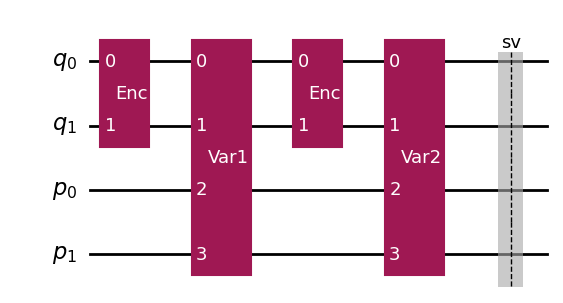


=== Method 2 circuit ===


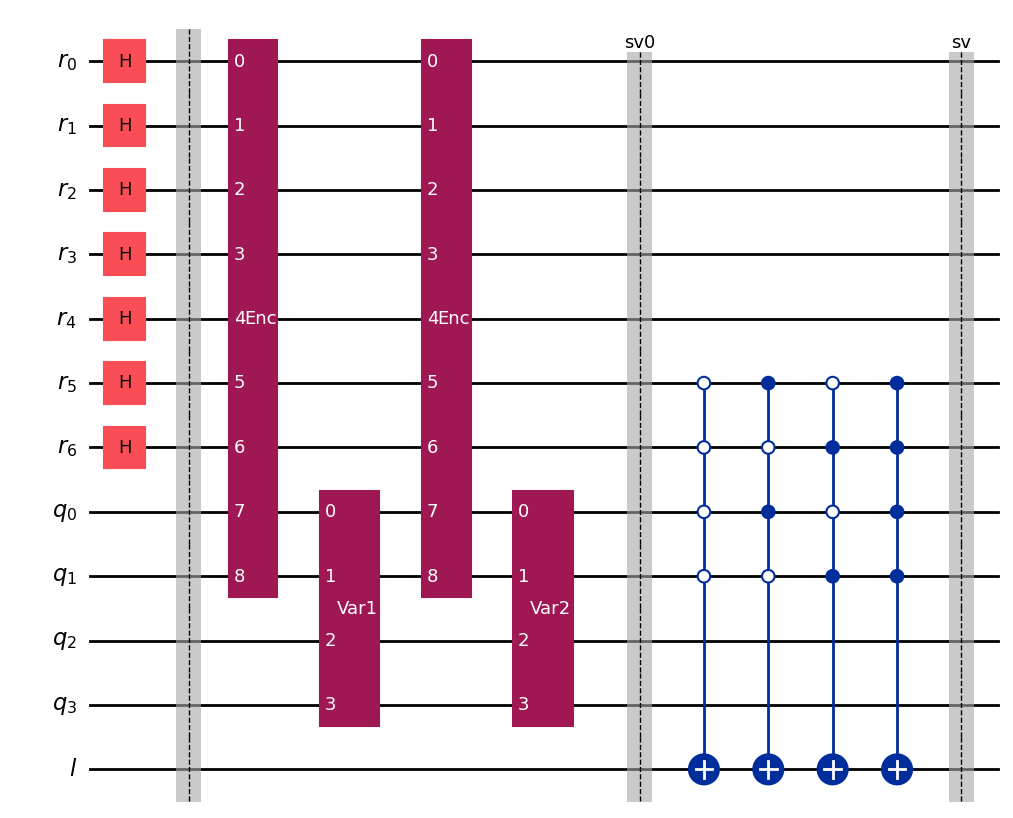

In [7]:
def make_backend(prefer_gpu=False):
    """Return an Aer statevector backend, falling back to CPU if GPU is unavailable."""
    if prefer_gpu:
        try:
            if 'GPU' in AerSimulator().available_devices():
                return AerSimulator(device='GPU')
            print("GPU device not available in qiskit-aer; using CPU.")
        except Exception as e:
            print(f"Could not initialise GPU backend ({e}); using CPU.")
    return AerSimulator()


# Draw the full circuit for each selected method (built on the first sample)
for m in METHODS:
    print(f"\n=== Method {m} circuit ===")
    if m == 1:
        display(qc1(train_data[0], np.zeros(num_parameters)).draw('mpl'))
    else:
        display(qc2(train_data, np.zeros(num_parameters)).draw('mpl', fold=-1))

## 6. Training / evaluation functions

Accuracy is always measured with the Method-1 per-sample circuit, so trained
parameters from either method are evaluated consistently. Labels are read out
as 2-bit strings (`'00'`, `'01'`, `'10'`, `'11'`) that map to classes 0–3.

In [8]:
def label_probability_1(state):
    # keep the readout register (the last `num_features` qubits), trace out the rest
    reduced = partial_trace(state, list(range(num_features, num_ansatz_q)))
    return reduced.probabilities_dict()


def classification_probability_1(all_data, variational):
    backend = make_backend(prefer_gpu=False)
    circs = [qc1(d, variational) for d in all_data]
    results = backend.run(transpile(circs, backend=backend)).result()
    return [label_probability_1(results.data(i)['sv']) for i in range(len(circs))]


def performance_evaluation(data, labels, variational):
    """Return (accuracy, predictions) using the Method-1 read-out."""
    probability = classification_probability_1(data, variational)
    predictions = [int(max(p, key=p.get), 2) for p in probability]
    accuracy = np.mean([int(pr == lb) for pr, lb in zip(predictions, labels)])
    return accuracy, predictions


# ----- Method 1 cost -----
def cross_entropy_loss_1(classification, expected):
    return -np.log(classification.get(expected))

def cost_function_1(all_data, labels, variational):
    classifications = classification_probability_1(all_data, variational)
    return sum(cross_entropy_loss_1(c, format(lb, '02b')) for c, lb in zip(classifications, labels)) / len(labels)

def objective_function_1(variational):
    return cost_function_1(train_data, train_labels, variational)


# ----- Method 2 cost -----
def label_probability_2(state):
    n = num_register + num_ansatz_q
    reduced = partial_trace(state, list(range(0, n)))
    return reduced.probabilities_dict()

def classification_probability_2(all_data, variational):
    backend = make_backend(prefer_gpu=USE_GPU)
    circ = qc2(all_data, variational)
    results = backend.run(transpile(circ, backend=backend)).result()
    return label_probability_2(results.data()['sv'])

def cross_entropy_loss_2(classification):
    return -np.log(classification.get('1'))

def cost_function_2(all_data, variational):
    return cross_entropy_loss_2(classification_probability_2(all_data, variational))

def objective_function_2(variational):
    return cost_function_2(train_data, variational)


class OptimizerLog:
    """Records SPSA progress and evaluates train/test accuracy each iteration."""
    def __init__(self):
        self.evaluations, self.parameters, self.costs = [], [], []
        self.train_accuracies, self.test_accuracies, self.stepsizes = [], [], []

    def update(self, evaluation, parameter, cost, stepsize, accepted):
        self.evaluations.append(evaluation)
        self.parameters.append(parameter.copy())
        self.costs.append(cost)
        self.stepsizes.append(stepsize)
        tr, _ = performance_evaluation(train_data, train_labels, parameter)
        te, _ = performance_evaluation(test_data,  test_labels,  parameter)
        self.train_accuracies.append(tr)
        self.test_accuracies.append(te)
        print(f" Iter {len(self.evaluations):3d}: loss={cost:.4f}  "
              f"train_acc={tr:.4f}  test_acc={te:.4f}  step={stepsize:.4f}")

## 7. Run training **or** load the saved results

The cell below loops over every method in `METHODS` and fills a `results`
dictionary — `results[m]["history"]` and `results[m]["final_params"]` — regardless
of whether you trained live (`MODE="train"`) or loaded the shipped results
(`MODE="load"`). All later cells iterate over the same `METHODS`.

The shipped result files are timestamped dumps
(`results_spsa_method{1,2}_<timestamp>.json`) produced directly by the original
training notebook, so "load" mode globs for the single matching file per
dataset/method instead of a fixed filename.

In [9]:
# results[method] = {"history": {...}, "final_params": np.ndarray}
results = {}

for METHOD in METHODS:
    print(f"\n########## Method {METHOD} ##########")
    if MODE == "train":
        from qiskit_machine_learning.optimizers import SPSA  # imported only when needed
        print(f"Training Method {METHOD} with SPSA ({MAXITER} iterations)...\n")
        initial_point = np.random.uniform(-np.pi, np.pi, size=num_parameters)
        log = OptimizerLog()
        objective = objective_function_1 if METHOD == 1 else objective_function_2
        optimizer = SPSA(maxiter=MAXITER, callback=log.update)
        result = optimizer.minimize(objective, initial_point)

        history = {
            "costs": log.costs,
            "train_accuracies": log.train_accuracies,
            "test_accuracies": log.test_accuracies,
            "stepsizes": log.stepsizes,
            "final_cost": float(result.fun),
        }
        final_params = result.x
        print(f"\nDone. Final cost = {result.fun:.6f}")

    else:  # MODE == "load"
        pattern = os.path.join(RESULTS_DIR, f"results_spsa_method{METHOD}_*.json")
        matches = sorted(glob.glob(pattern))
        assert matches, f"No result file found matching: {pattern}"
        json_path = matches[-1]   # most recent if more than one
        print(f"Loading saved results from: {json_path}")
        with open(json_path, encoding="utf-8") as f:
            saved = json.load(f)
        th = saved["training_history"]
        fr = saved["final_results"]
        history = {
            "costs": th["costs"],
            "train_accuracies": th["train_accuracies"],
            "test_accuracies": th["test_accuracies"],
            "stepsizes": th["stepsizes"],
            "final_cost": fr["final_cost"],
        }
        final_params = np.array(fr["final_parameters"])
        print(f"Loaded {len(history['costs'])} iterations  "
              f"(optimizer: {saved['experiment_info']['optimizer']})")

    results[METHOD] = {"history": history, "final_params": final_params}


########## Method 1 ##########
Loading saved results from: results\checkerboard-4L-4Q-dataset1\results_spsa_method1_20250813_130633.json
Loaded 400 iterations  (optimizer: SPSA_Method1)

########## Method 2 ##########
Loading saved results from: results\checkerboard-4L-4Q-dataset1\results_spsa_method2_20250813_203021.json
Loaded 400 iterations  (optimizer: SPSA_Method2)


## 8. Training curves

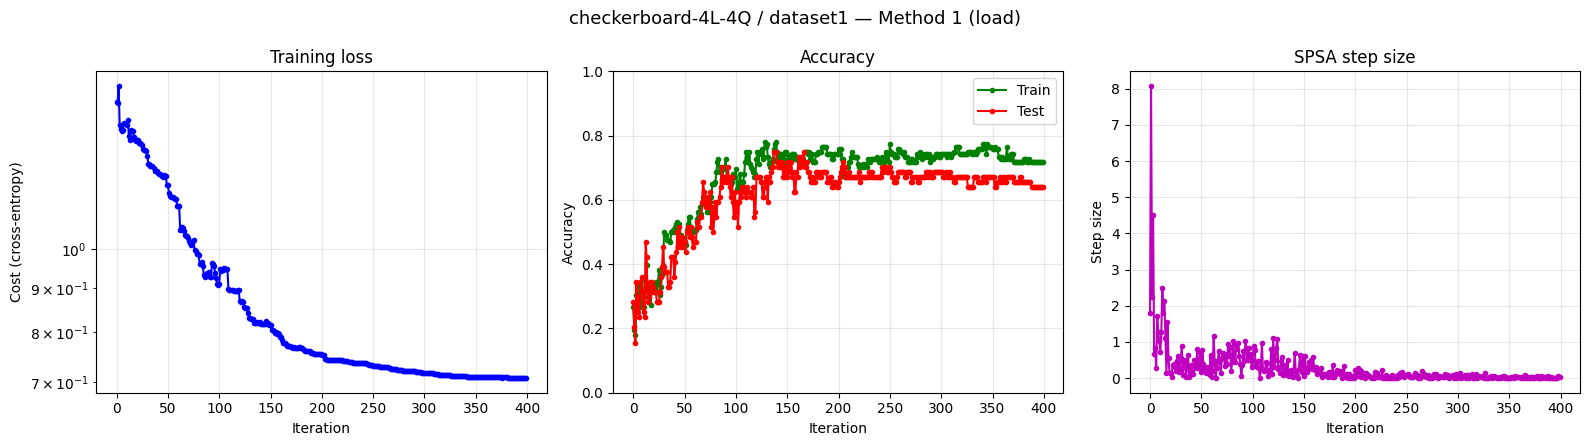

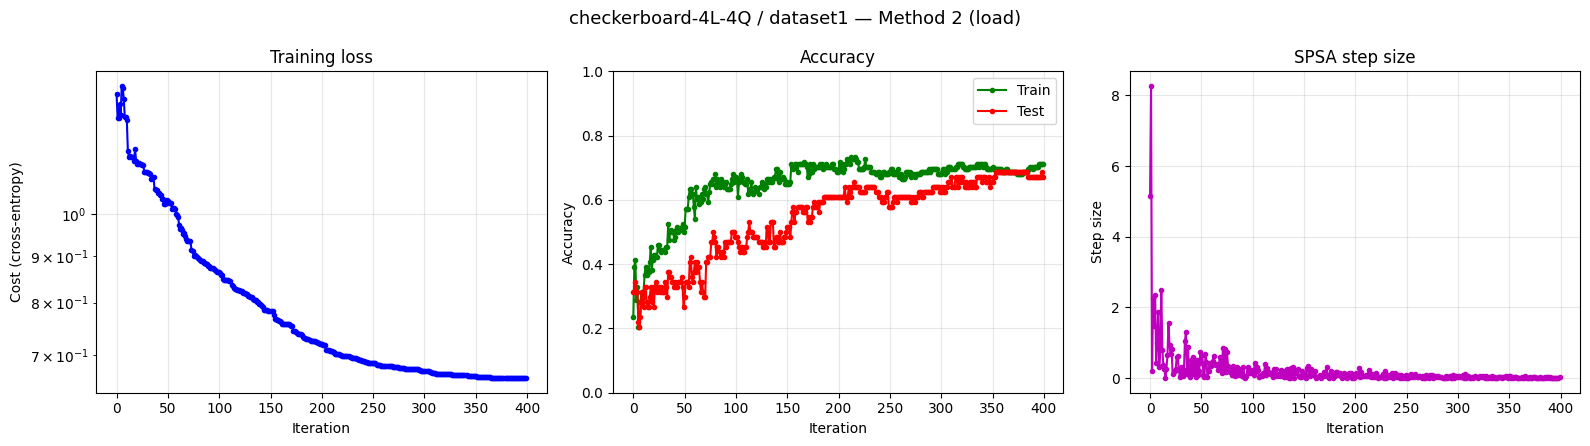

In [10]:
for METHOD in METHODS:
    history = results[METHOD]["history"]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(history["costs"], 'b-o', ms=3)
    ax[0].set_yscale('log'); ax[0].set_title("Training loss")
    ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("Cost (cross-entropy)")
    ax[0].grid(alpha=0.3)

    ax[1].plot(history["train_accuracies"], 'g-o', ms=3, label="Train")
    ax[1].plot(history["test_accuracies"],  'r-o', ms=3, label="Test")
    ax[1].set_ylim(0, 1); ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Accuracy")
    ax[1].legend(); ax[1].grid(alpha=0.3)

    ax[2].plot(history["stepsizes"], 'm-o', ms=3)
    ax[2].set_title("SPSA step size")
    ax[2].set_xlabel("Iteration"); ax[2].set_ylabel("Step size")
    ax[2].grid(alpha=0.3)

    fig.suptitle(f"checkerboard-4L-4Q / dataset{DATASET_NUM} — Method {METHOD} ({MODE})",
                 fontsize=13)
    plt.tight_layout(); plt.show()

## 9. Predictions and decision boundary

Predictions are computed with the trained parameters. The decision boundary
(4 discrete classes) is evaluated on a grid using the Method-1 read-out (set
`PLOT_DECISION_BOUNDARY=False` in the config to skip the slower grid evaluation).

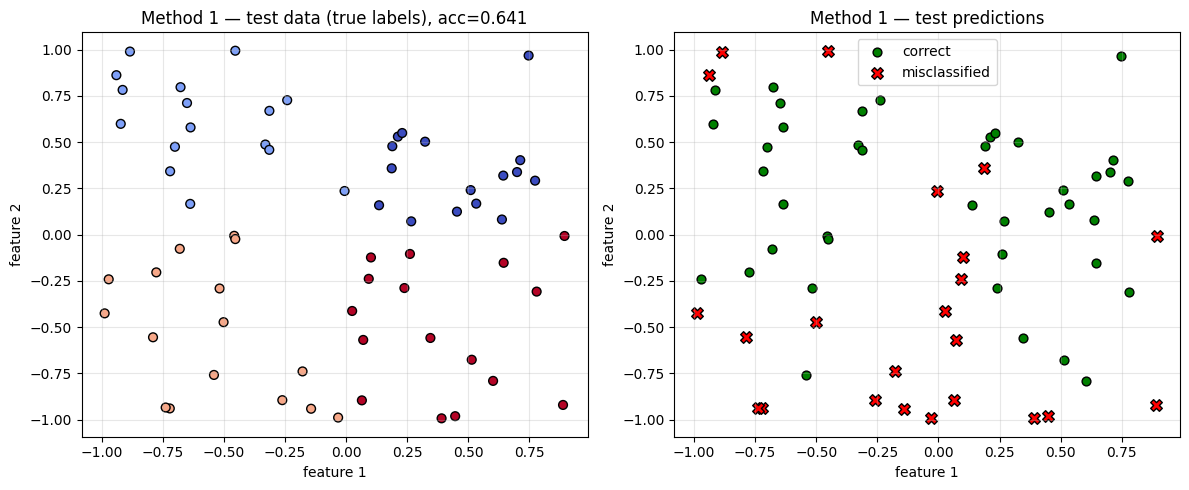

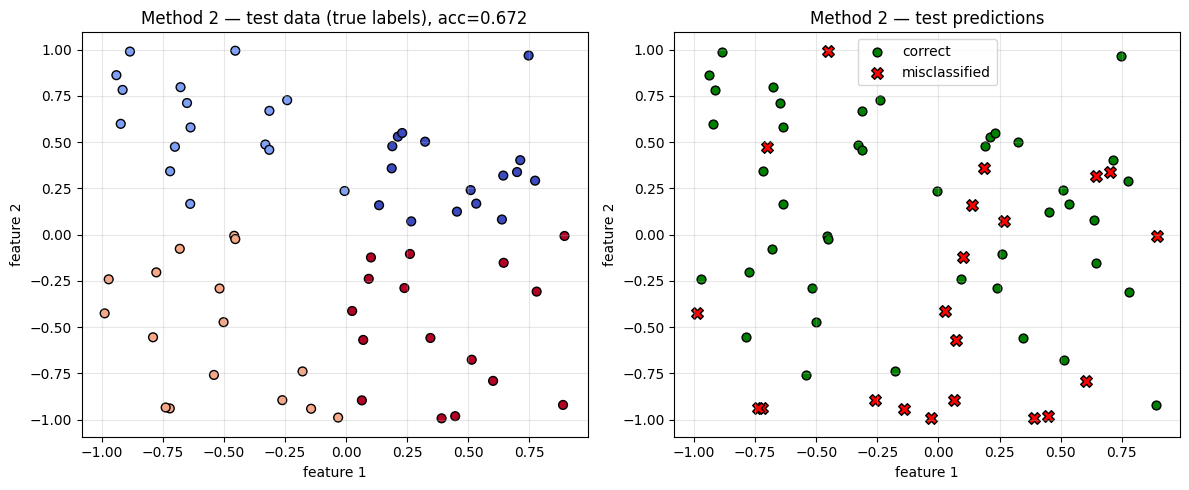

In [11]:
# Pre-compute the decision-boundary grid once (shared geometry across methods)
if PLOT_DECISION_BOUNDARY:
    allX = np.vstack([train_data, test_data])
    pad = 0.2
    x_min, x_max = allX[:, 0].min() - pad, allX[:, 0].max() + pad
    y_min, y_max = allX[:, 1].min() - pad, allX[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, GRID_RES),
                         np.linspace(y_min, y_max, GRID_RES))
    grid = np.c_[xx.ravel(), yy.ravel()]

for METHOD in METHODS:
    final_params = results[METHOD]["final_params"]
    final_train_acc, train_pred = performance_evaluation(train_data, train_labels, final_params)
    final_test_acc,  test_pred  = performance_evaluation(test_data,  test_labels,  final_params)
    test_pred = np.array(test_pred)
    # stash for the summary cell
    results[METHOD]["final_train_acc"] = final_train_acc
    results[METHOD]["final_test_acc"]  = final_test_acc

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if PLOT_DECISION_BOUNDARY:
        print(f"Method {METHOD}: evaluating {GRID_RES}x{GRID_RES} decision-boundary grid...")
        probs = classification_probability_1(grid, final_params)
        zz = np.array([int(max(p, key=p.get), 2) for p in probs]).reshape(xx.shape)
        for ax in axes:
            ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
                       cmap=CLASS_COLORS, norm=CLASS_NORM, alpha=0.45)

    ax = axes[0]
    ax.scatter(test_data[:, 0], test_data[:, 1], c=test_labels, cmap=CLASS_COLORS,
               norm=CLASS_NORM, edgecolors="k", s=40)
    ax.set_title(f"Method {METHOD} — test data (true labels), acc={final_test_acc:.3f}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2"); ax.grid(alpha=0.3)

    ax = axes[1]
    correct = test_pred == test_labels
    ax.scatter(test_data[correct, 0], test_data[correct, 1], c="green",
               edgecolors="k", s=40, label="correct")
    ax.scatter(test_data[~correct, 0], test_data[~correct, 1], c="red",
               marker="X", edgecolors="k", s=70, label="misclassified")
    ax.set_title(f"Method {METHOD} — test predictions")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

## 10. Final performance summary

In [12]:
print(f"Dataset: checkerboard-4L-4Q / dataset{DATASET_NUM}    Mode: {MODE}\n")

rows = []
for METHOD in METHODS:
    h = results[METHOD]["history"]
    rows.append({
        "method": METHOD,
        "final_train_acc": round(results[METHOD]["final_train_acc"], 4),
        "final_test_acc":  round(results[METHOD]["final_test_acc"], 4),
        "best_test_acc":   round(max(h["test_accuracies"]), 4),
        "best_train_acc":  round(max(h["train_accuracies"]), 4),
        "final_cost":      round(h["final_cost"], 6),
    })

summary_methods = pd.DataFrame(rows).set_index("method")
display(summary_methods)

Dataset: checkerboard-4L-4Q / dataset1    Mode: load



,final_train_acc,final_test_acc,best_test_acc,best_train_acc,final_cost
method,,,,,
1,0.7188,0.6406,0.7500,0.7812,0.707387
2,0.7109,0.6719,0.6875,0.7344,0.661091


## 11. (Optional) Compare all 10 instances

A quick aggregate view across `dataset1` … `dataset10` for the chosen `METHOD`,
read from the saved results. This does not depend on the single-dataset
selection above.


===== checkerboard-4L-4Q — Method 1 (all 10 instances) =====


,final_test_acc,best_test_acc,final_train_acc,final_cost
dataset,,,,
1,0.6406,0.7500,0.7188,0.7074
2,0.6875,0.7656,0.6641,0.7877
3,0.4688,0.5000,0.5391,1.0882
4,0.4531,0.5469,0.6250,1.0376
5,0.7031,0.7812,0.7734,0.7633
6,0.7188,0.7969,0.7812,0.7197
7,0.3594,0.4219,0.4688,1.2020
8,0.7344,0.7500,0.7188,0.7444
9,0.4062,0.4844,0.6016,1.0314


Mean final test accuracy: 0.5687 ± 0.1429


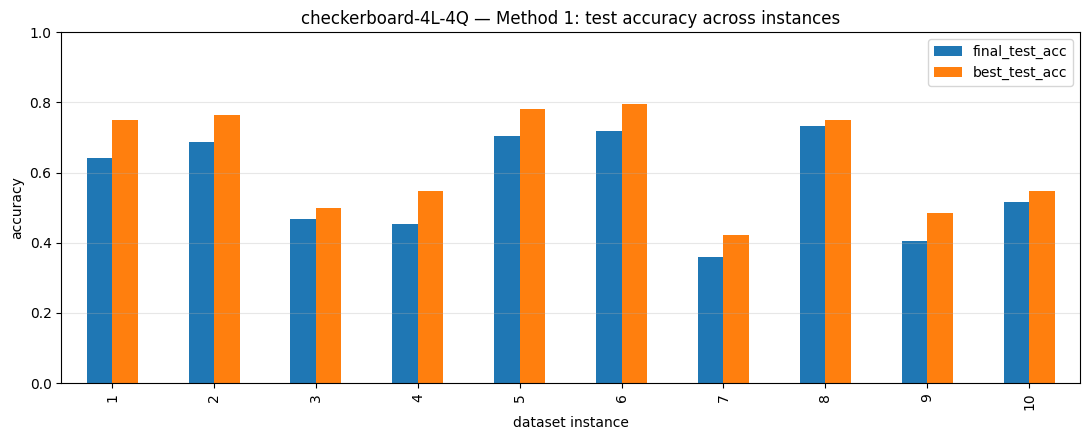


===== checkerboard-4L-4Q — Method 2 (all 10 instances) =====


,final_test_acc,best_test_acc,final_train_acc,final_cost
dataset,,,,
1,0.6719,0.6875,0.7109,0.6611
2,0.4844,0.5000,0.4922,0.8714
3,0.7656,0.8438,0.7188,0.6841
4,0.6719,0.7500,0.6719,0.6079
5,0.5156,0.5781,0.5469,0.7699
6,0.5938,0.6250,0.6250,0.7805
7,0.5469,0.6094,0.5547,0.8357
8,0.5625,0.6562,0.4609,0.9412
9,0.4844,0.5000,0.5859,0.8033


Mean final test accuracy: 0.5828 ± 0.0929


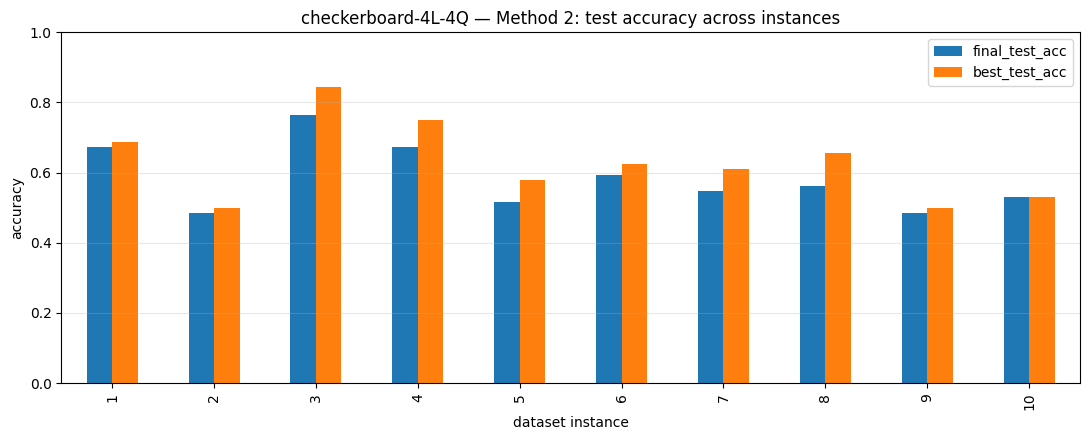

In [13]:
for METHOD in METHODS:
    rows = []
    for n in range(1, 11):
        pattern = os.path.join("results", f"checkerboard-4L-4Q-dataset{n}",
                               f"results_spsa_method{METHOD}_*.json")
        matches = sorted(glob.glob(pattern))
        if not matches:
            continue
        with open(matches[-1], encoding="utf-8") as f:
            s = json.load(f)
        fr, th = s["final_results"], s["training_history"]
        rows.append({
            "dataset": n,
            "final_test_acc": fr["final_test_accuracy"],
            "best_test_acc":  max(th["test_accuracies"]),
            "final_train_acc": fr["final_train_accuracy"],
            "final_cost": fr["final_cost"],
        })

    summary = pd.DataFrame(rows).set_index("dataset")
    print(f"\n===== checkerboard-4L-4Q — Method {METHOD} (all 10 instances) =====")
    display(summary.round(4))
    print(f"Mean final test accuracy: "
          f"{summary['final_test_acc'].mean():.4f} ± {summary['final_test_acc'].std():.4f}")

    ax = summary[["final_test_acc", "best_test_acc"]].plot.bar(figsize=(11, 4.5))
    ax.set_title(f"checkerboard-4L-4Q — Method {METHOD}: test accuracy across instances")
    ax.set_xlabel("dataset instance"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()